In [2]:
import pandas as pd

ratings = pd.read_csv(
    "../data/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

print("Ratings shape:", ratings.shape)
print(ratings.head())
print("\nUnique users:", ratings["user_id"].nunique())
print("Unique items:", ratings["item_id"].nunique())

Ratings shape: (100000, 4)
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596

Unique users: 943
Unique items: 1682


In [3]:
total_possible = ratings["user_id"].nunique() * ratings["item_id"].nunique()
actual = len(ratings)
sparsity = 1 - (actual / total_possible)

print(f"Total possible ratings: {total_possible}")
print(f"Actual ratings: {actual}")
print(f"Sparsity: {sparsity:.4f}")

Total possible ratings: 1586126
Actual ratings: 100000
Sparsity: 0.9370


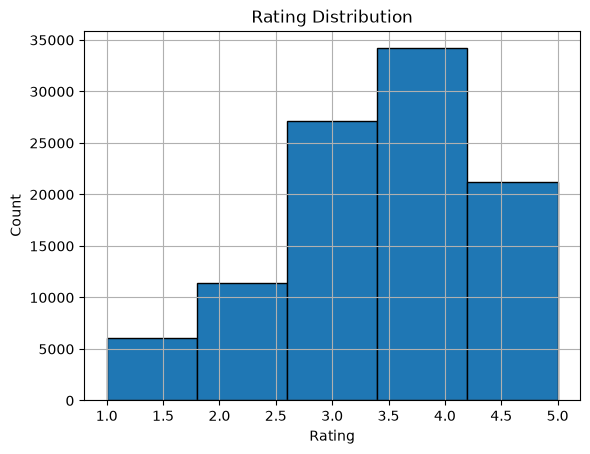

In [4]:
import matplotlib.pyplot as plt

ratings["rating"].hist(bins=5, edgecolor="black")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.savefig("../outputs/rating_distribution.png")
plt.show()

In [5]:
import sys
sys.path.append("../src")

from clustering import build_user_features, find_optimal_k, cluster_users
from sklearn.preprocessing import StandardScaler

user_features = build_user_features(ratings)
print(user_features.head())
print("\nTotal users:", len(user_features))

   user_id  avg_rating  num_ratings  rating_std
0        1    3.610294          272    1.263585
1        2    3.709677           62    1.030472
2        3    2.796296           54    1.219026
3        4    4.333333           24    0.916831
4        5    2.874286          175    1.362963

Total users: 943


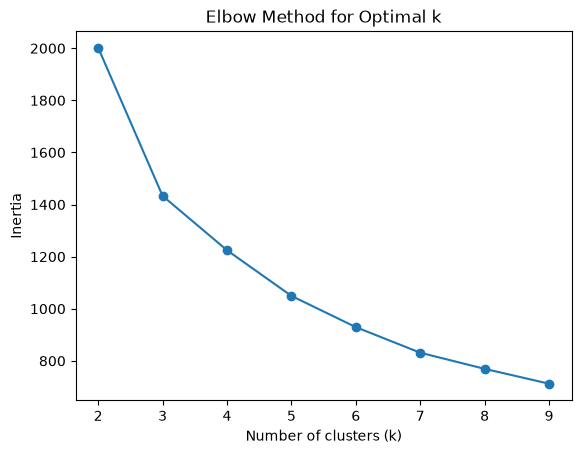

In [7]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    user_features[["avg_rating", "num_ratings", "rating_std"]]
)

k_range, inertia = find_optimal_k(scaled_features)

import matplotlib.pyplot as plt

plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.savefig("../outputs/elbow_plot.png")
plt.show()

In [8]:
user_features, kmeans_model, scaler = cluster_users(user_features, n_clusters=5)

print(user_features.head())
print("\nCluster sizes:")
print(user_features["cluster_id"].value_counts())

   user_id  avg_rating  num_ratings  rating_std  cluster_id
0        1    3.610294          272    1.263585           3
1        2    3.709677           62    1.030472           4
2        3    2.796296           54    1.219026           0
3        4    4.333333           24    0.916831           1
4        5    2.874286          175    1.362963           0

Cluster sizes:
cluster_id
4    272
1    181
0    175
2    172
3    143
Name: count, dtype: int64


In [9]:
cluster_summary = user_features.groupby("cluster_id")[
    ["avg_rating", "num_ratings", "rating_std"]
].mean()

print(cluster_summary)

            avg_rating  num_ratings  rating_std
cluster_id                                     
0             3.105929    67.422857    1.282812
1             4.107342    70.237569    0.802355
2             3.349856    71.279070    0.873182
3             3.468769   298.629371    1.020820
4             3.766502    75.455882    1.087745


In [10]:
user_features.to_csv("../data/user_clusters.csv", index=False)
print("Saved.")

Saved.


## Cluster Interpretation

- **Cluster 0** — Critical/inconsistent raters: below-average scores with the highest rating variance.
- **Cluster 1** — Generous, consistent fans: highest average rating, lowest variance.
- **Cluster 2** — Steady moderate raters: middle-of-the-road scores, low variance.
- **Cluster 3** — Power users: rate ~4x more items than any other segment, average scores.
- **Cluster 4** — Typical users: slightly above-average ratings, largest group (272 users).